[IPYKERNEL_LAUNCHER]INFO      Initialized DataRequest class with base_url: https://rsm.ane.gov.co:12443/api
[IPYKERNEL_LAUNCHER]INFO      Loading data for campaigns: ['FM original'] and nodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

🚀 Starting Campaign: FM original


  ↳ Node 1: 1page [00:06,  6.71s/page]
  ↳ Node 2: 1page [00:06,  6.18s/page]
  ↳ Node 3: 1page [00:07,  7.44s/page]
  ↳ Node 4: 1page [00:05,  5.75s/page]
  ↳ Node 5: 1page [00:06,  6.16s/page]
  ↳ Node 6: 1page [00:05,  5.32s/page]
  ↳ Node 7: 1page [00:05,  5.52s/page]
  ↳ Node 8: 1page [00:01,  1.51s/page]
  ↳ Node 9: 1page [00:06,  6.19s/page]
  ↳ Node 10: 1page [00:05,  5.66s/page]

[IPYKERNEL_LAUNCHER]INFO      Finished loading data for all campaigns and nodes.


Parsing pxx across 10 nodes...


100%|██████████| 10/10 [00:01<00:00,  7.05it/s]



Parsed 31,686,656 values total
  7,977 values (0.03%) fall outside (-27, 6)


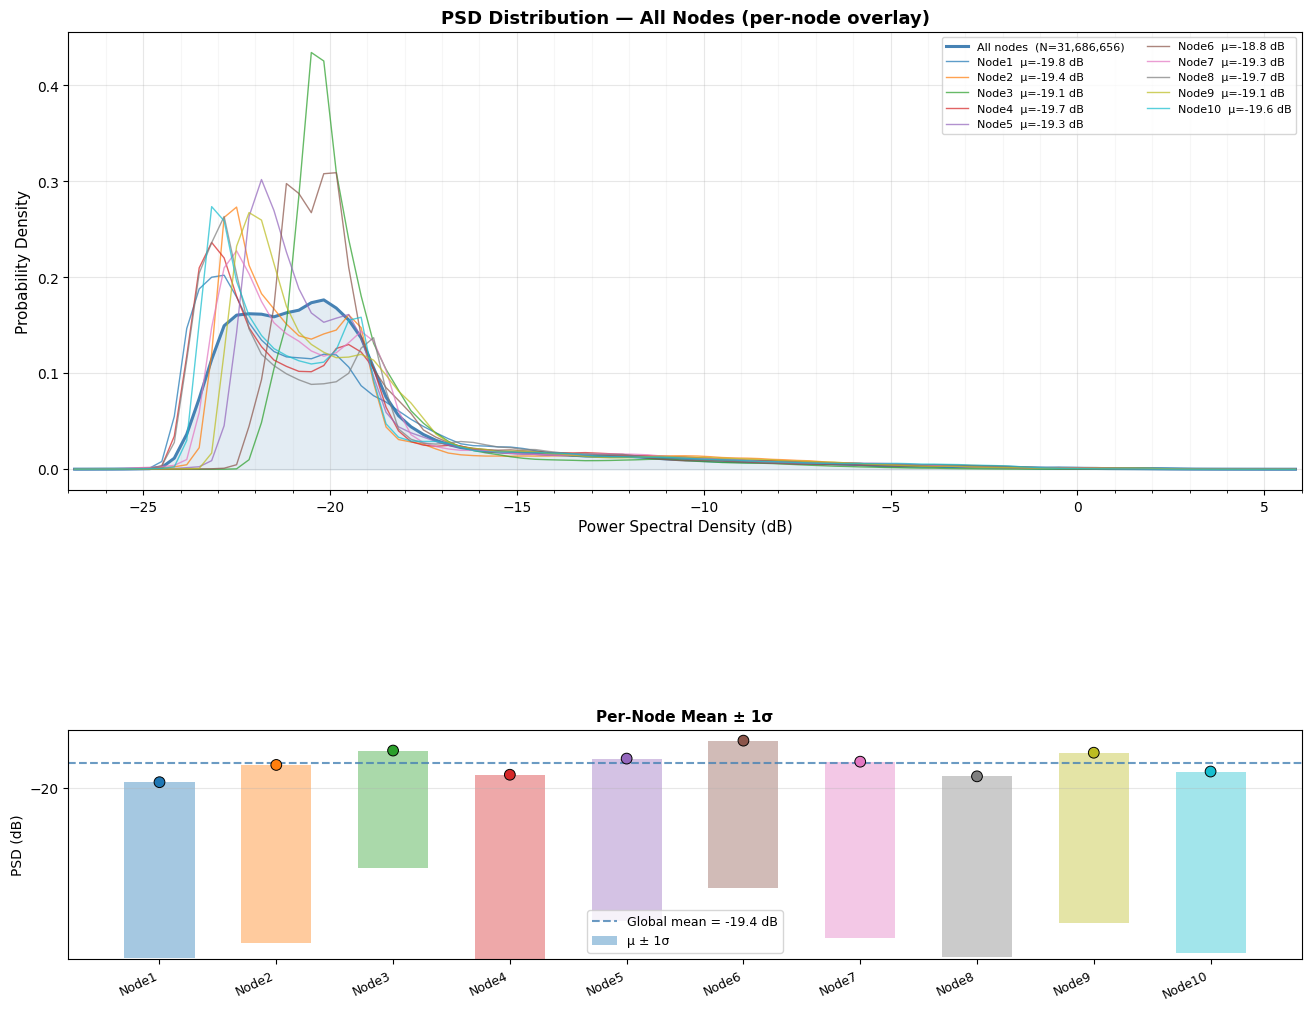


Node                  Mean (dB)   Std (dB)   Rows       Values
--------------------------------------------------------------
Node1                    -19.85       4.29    105    3,439,202
Node2                    -19.43       4.35    105    3,439,350
Node3                    -19.08       2.87    105    3,439,687
Node4                    -19.67       4.50    105    3,440,516
Node5                    -19.27       3.98    105    3,440,039
Node6                    -18.83       3.59    105    3,440,031
Node7                    -19.35       4.32    105    3,438,978
Node8                    -19.71       4.42     23      753,371
Node9                    -19.13       4.17    105    3,440,357
Node10                   -19.59       4.42    104    3,407,148
--------------------------------------------------------------
GLOBAL                   -19.39       0.30          31,686,656

📊 Ranked by absolute mean cross-node similarity:
  1. Node7                  | abs mean r = 0.8399
  2. Node2       

In [2]:
import cfg
from libs.data_request import DataRequest
from libs.analysis import PSDHistogram

# =============================================================================
# EXECUTION
# =============================================================================
if __name__ == "__main__":

    log = cfg.set_logger()
    dr = DataRequest(log=log, base_url=cfg.API_URL)
    
    camp_ids = {'FM original': 176}
    target_nodes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    
    df_full = dr.load_campaigns_and_nodes(campaigns=camp_ids, node_ids=target_nodes)
    datos_nodos = df_full["FM original"]

    # Instantiation is now simpler:
    analyzer = PSDHistogram(datos_nodos, global_range=(-27, 6))
    analyzer.run()